In [ ]:
# 01 문제정의
# 02 데이터가져오기
# 03 EDA
# 04 데이터전처리
# 05 검증데이터 분할 및 학습
# 06 테스트 및 검증지표 확인
# 07 Model 내보내기 , 테스트파일 내보내기

In [ ]:
#----------------------------------------
# 01 문제정의
#----------------------------------------
## 건강 설문으로 질병 여부 예측
## 타깃(라벨, y값) : disease  ->  0(없음) / 1(있음)
##
## 목적 : 나이·체질량·흡연·활동량으로 질병 위험을 판정한다.

In [ ]:
#----------------------------------------
#02 데이터가져오기
#----------------------------------------

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('health_survey.csv')
print(df.shape)                     # (1000, 5)
print(df['disease'].value_counts()) # 질병 1 → 588 | 0 → 412 (약 59:41 약한 불균형)
df.head()

(1000, 5)
disease
1    588
0    412
Name: count, dtype: int64


,age,bmi,smoker,activity_level,disease
0,62,35.179089,0,0,1
1,65,18.576042,0,2,1
2,71,33.178426,0,1,1
3,18,37.063007,1,2,0
4,21,17.613266,0,0,0


In [ ]:
#----------------------------------------
# 03 EDA
#----------------------------------------

In [2]:
# 타깃 분포 - 04에서 하던 그대로
print(df['disease'].value_counts())

disease
1    588
0    412
Name: count, dtype: int64


In [3]:
print('결측:', df.isnull().sum().sum())   # 0
df.describe().round(2)

결측: 0


,age,bmi,smoker,activity_level,disease
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,48.17,24.81,0.30,0.96,0.59
std,18.01,7.87,0.46,0.82,0.49
min,18.00,1.31,0.00,0.00,0.00
25%,33.00,19.56,0.00,0.00,0.00
50%,48.00,25.22,0.00,1.00,1.00
75%,64.00,29.98,1.00,2.00,1.00
max,79.00,49.46,1.00,2.00,1.00


In [4]:
# 상관계수로 한 번 더 확인
df.corr()['disease'].sort_values(ascending=False)

disease           1.000000
bmi               0.209308
age               0.154159
smoker            0.068314
activity_level   -0.088498
Name: disease, dtype: float64

In [5]:
# 특성별 질병률 - 방향이 상식과 맞나
print(df.groupby(pd.cut(df['age'], [17,35,50,65,80]), observed=True)['disease'].mean().round(3))
print(df.groupby('smoker')['disease'].mean().round(3))
print(df.groupby('activity_level')['disease'].mean().round(3))

age
(17, 35]    0.483
(35, 50]    0.571
(50, 65]    0.650
(65, 80]    0.674
Name: disease, dtype: float64
smoker
0    0.566
1    0.640
Name: disease, dtype: float64
activity_level
0    0.647
1    0.568
2    0.542
Name: disease, dtype: float64


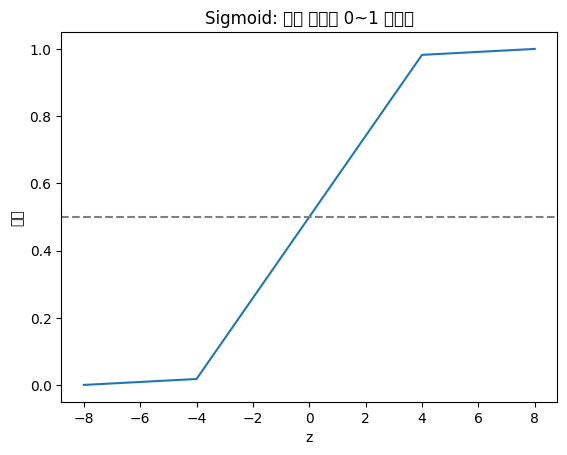

In [25]:
import matplotlib.pyplot as plt
# -8부터 8까지를 '똑같은 간격으로 100개' 나눈 배열. 곡선을 매끄럽게 그리려는 점들.
# z = np.linspace(-8, 8, 100) # [-8,,8]
z = np.linspace(-8, 8, 5) # [-8. -4.  0.  4.  8.]

# 시그모이드 공식. np.exp(-z)는 e^(-z). 배열 z 전체에 한 번에 적용된다(numpy 벡터 연산).
# z : [-8. -4.  0.  4.  8.] | -z : [ 8,  4,  0, -4, -8] 
sigmoid = 1 / (1 + np.exp(-z))

# np.exp(-z)     = [2980.96, 54.60,  1.00,  0.0183, 0.000335]
# 1 + np.exp(-z)    = [2981.96, 55.60,  2.00,  1.0183, 1.000335]
# 1 / 1 + np.exp(-z)     = [ 0.0003, 0.0180, 0.5000, 0.9820, 0.99966]


plt.plot(z, sigmoid)
plt.axhline(0.5, color='gray', linestyle='--')
plt.xlabel('z'); plt.ylabel('확률')
plt.title('Sigmoid: 어떤 값이든 0~1 확률로')
plt.show()

In [ ]:
#----------------------------------------

#----------------------------------------

In [7]:
from sklearn.model_selection import train_test_split
y = df['disease']
X = df.drop(columns=['disease'])
print('X:', X.shape, '| y:', y.shape)   # (1000, 4) (1000,)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
print(X_tr.shape, X_val.shape)          # (800, 4) (200, 4)

X: (1000, 4) | y: (1000,)
(800, 4) (200, 4)


In [8]:
X_tr

,age,bmi,smoker,activity_level
791,64,25.616912,1,2
506,60,28.315943,0,2
890,64,28.948245,0,0
516,74,26.866151,0,2
537,41,20.700514,0,1
...,...,...,...,...
769,30,18.610713,0,2
470,44,25.770486,0,1
696,53,20.908883,0,2
821,76,16.170908,0,2


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)   # train으로 기준 학습
X_val_s = scaler.transform(X_val)     # 같은 기준으로 변환만
print('배운 평균  :', scaler.mean_.round(2))    # [48.49 24.8  0.31 0.97]
print('배운 표준편차:', scaler.scale_.round(2))  # [17.99  7.8  0.46 0.82]

배운 평균  : [48.49 24.8   0.31  0.97]
배운 표준편차: [17.99  7.8   0.46  0.82]


In [10]:
X_tr_s

array([[ 0.86202272,  0.10528276,  1.50509339,  1.25219287],
       [ 0.63970868,  0.45115997, -0.6644106 ,  1.25219287],
       [ 0.86202272,  0.53218862, -0.6644106 , -1.1792496 ],
       ...,
       [ 0.25065909, -0.49804466, -0.6644106 ,  1.25219287],
       [ 1.52896487, -1.10520974, -0.6644106 ,  1.25219287],
       [ 1.30665082, -0.43271048, -0.6644106 ,  0.03647164]],
      shape=(800, 4))

In [ ]:
#----------------------------------------

#----------------------------------------

In [11]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_tr_s, y_tr)
print('계수:', model.coef_[0].round(4))   # [0.3587 0.436 0.1158 -0.2426]

계수: [ 0.3587  0.436   0.1158 -0.2426]


In [12]:
pred = model.predict(X_val_s)               # 0 또는 1
proba = model.predict_proba(X_val_s)[:, 1]  # 질병일 확률
compare = pd.DataFrame({'예측': pred[:5], '질병확률': proba[:5].round(3)})
compare

,예측,질병확률
0,1,0.641
1,1,0.576
2,1,0.567
3,0,0.346
4,1,0.703


In [ ]:
#----------------------------------------

#----------------------------------------

In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
print('정확도 :', round(accuracy_score(y_val, pred), 4))   # 약 0.615
print('ROC-AUC:', round(roc_auc_score(y_val, proba), 4))   # 약 0.627 (0.6271)
print(classification_report(y_val, pred))
# 실측 출력:
#         precision  recall  f1   support
#   0        0.54     0.44  0.48    82
#   1        0.65     0.74  0.69   118
#  accuracy                 0.61   200

정확도 : 0.615
ROC-AUC: 0.6271
              precision    recall  f1-score   support

           0       0.54      0.44      0.48        82
           1       0.65      0.74      0.69       118

    accuracy                           0.61       200
   macro avg       0.60      0.59      0.59       200
weighted avg       0.61      0.61      0.61       200



In [ ]:
#----------------------------------------

#----------------------------------------

In [15]:
import joblib, os
joblib.dump(model, 'model_disease.pkl')
joblib.dump(scaler, 'scaler_disease.pkl')   # 이걸 빠뜨리면 재앙
print('모델    :', os.path.getsize('model_disease.pkl'), 'B')    # 879 B
print('스케일러:', os.path.getsize('scaler_disease.pkl'), 'B')   # 967 B

모델    : 895 B
스케일러: 1063 B


In [16]:
# 새 환자 한 명 - 스케일러를 빠뜨리면 어떻게 되나
loaded_model  = joblib.load('model_disease.pkl')
loaded_scaler = joblib.load('scaler_disease.pkl')
new = pd.DataFrame([{'age': 60, 'bmi': 31.0, 'smoker': 1, 'activity_level': 0}])
print('스케일러 O -> 질병확률 %.3f' % loaded_model.predict_proba(loaded_scaler.transform(new))[0, 1])  # 0.806
print('스케일러 X -> 질병확률 %.3f' % loaded_model.predict_proba(new)[0, 1])                            # 1.000

스케일러 O -> 질병확률 0.806
스케일러 X -> 질병확률 1.000


/opt/conda/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [17]:
pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)

bmi               0.435980
age               0.358733
smoker            0.115811
activity_level   -0.242586
dtype: float64

In [18]:
m_raw = LogisticRegression().fit(X_tr, y_tr)     # 스케일링 안 한 원본으로 학습
p_raw  = m_raw.predict(X_val)
pr_raw = m_raw.predict_proba(X_val)[:, 1]
print('[O] 정확도 %.4f | AUC %.4f' % (accuracy_score(y_val, pred),   roc_auc_score(y_val, proba)))    # 0.615 0.6271
print('[X] 정확도 %.4f | AUC %.4f' % (accuracy_score(y_val, p_raw), roc_auc_score(y_val, pr_raw)))    # 0.615 0.626
print(pd.Series(m_raw.coef_[0], index=X.columns).round(4))
# 원본 계수:  activity_level -0.294 | smoker 0.246 | bmi 0.056 | age 0.020

[O] 정확도 0.6150 | AUC 0.6271
[X] 정확도 0.6150 | AUC 0.6260
age               0.0201
bmi               0.0562
smoker            0.2456
activity_level   -0.2941
dtype: float64


In [21]:
from sklearn.metrics import recall_score, precision_score
for t in [0.5, 0.3]:
    pt = (proba >= t).astype(int) # 질병걸릴확률의 임계값(0.5, 0.3) 으로 지정한다음  질병여부를 pt배열[1,0,1..] 로 처리
    print('임계값 %.1f -> 정확도 %.4f | recall %.4f | precision %.4f'
          % (t, accuracy_score(y_val, pt), recall_score(y_val, pt), precision_score(y_val, pt)))
# 임계값 0.5 -> 정확도 0.6150 | recall 0.7373 | precision 0.6541
# 임계값 0.3 -> 정확도 0.6150 | recall 1.0000 | precision 0.6051

임계값 0.5 -> 정확도 0.6150 | recall 0.7373 | precision 0.6541
임계값 0.3 -> 정확도 0.6150 | recall 1.0000 | precision 0.6051


In [ ]:
#
# # 검증셋의 진짜 z로 그리기
# ---------------------------------------------

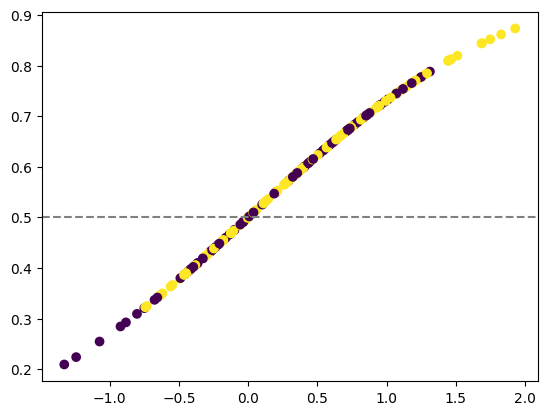

In [27]:
z_val = X_val_s @ model.coef_[0] + model.intercept_[0]
plt.scatter(z_val, proba, c=y_val)
plt.axhline(0.5, color='gray', linestyle='--')
plt.show()